# Lab 4: Improving and Comparing Machine Learning Models

**Name:** Haseeb Hassan

**Student ID:** 023-24-0274

**Section:** H

**GitHub Profile:** [Haseeb-Hassan66](https://github.com/Haseeb-Hassan66)

**Kaggle Profile:** [haseebsamo66737](https://www.kaggle.com/haseebsamo66737)

**Dataset:** Telco Customer Churn (cleaned in Lab 2 — `clean_churn.csv`)

**Dataset Source:** [Telco Customer Churn — Kaggle](https://github.com/Haseeb-Hassan66/ML-Practice/blob/main/Week%202/telco-churn.csv)

---

## Part 1 — Decision Tree Baseline Review 

**Tasks 1–2**
1. Re-load your cleaned Lab 2 dataset and recreate the same X/y and train/test split you used in Lab 3 (same random_state). 
2. Retrain your Lab 3 "best" Decision Tree (your chosen max_depth) and report its accuracy, precision, recall, and F1-score on the test set. This is your benchmark for the rest of the lab. 

In [1]:
# Task 1 — reload the cleaned dataset and recreate the Lab 3 features/split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("clean_churn.csv")

# Recreate the target exactly as in Lab 3: No -> 0, Yes -> 1
y = df['Churn'].map({'No': 0, 'Yes': 1})

# Recreate the features exactly as in Lab 3: drop target, one-hot encode categoricals
X = df.drop(columns=['Churn'])
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (7043, 30)
y distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [2]:
# Recreate the same train/test split as Lab 3 (80/20, stratified, random_state=42)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Churn rate — train:", round(y_train.mean(), 4), " test:", round(y_test.mean(), 4))

X_train: (5634, 30)  X_test: (1409, 30)
Churn rate — train: 0.2654  test: 0.2654


In [3]:
# Task 2 — retrain the Lab 3 "best" Decision Tree (max_depth=4, gini, random_state=42)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

dt_metrics = {
    "Accuracy": accuracy_score(y_test, dt_test_pred),
    "Precision": precision_score(y_test, dt_test_pred),
    "Recall": recall_score(y_test, dt_test_pred),
    "F1-score": f1_score(y_test, dt_test_pred),
}

dt_benchmark_table = pd.DataFrame({
    "Metric": list(dt_metrics.keys()),
    "Decision Tree (depth=4)": [round(v, 4) for v in dt_metrics.values()]
})
dt_benchmark_table

,Metric,Decision Tree (depth=4)
0,Accuracy,0.7835
1,Precision,0.5856
2,Recall,0.6310
3,F1-score,0.6075


**Observation:** The Decision Tree achieved **78.35% accuracy**, **58.56% precision**, **63.10% recall**, and an **F1-score of 60.75%** on the test set. These results will be used as the baseline for comparison with the Random Forest model.

---

## Part 2 — Random Forest 

**Tasks 3–4**

3. Train a `RandomForestClassifier` on the same training data (reasonable default `n_estimators`, e.g. 100–300; fixed `random_state`). Generate predictions on the test set.

4. Explain in 1–2 sentences why a Random Forest might generalize better than a single unrestricted Decision Tree.

In [4]:
# Task 3 — train a default Random Forest on the same train/test split
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

print("Random Forest trained with n_estimators=200, random_state=42.")
print("Train accuracy:", round(accuracy_score(y_train, rf_train_pred), 4))
print("Test accuracy:", round(accuracy_score(y_test, rf_test_pred), 4))

Random Forest trained with n_estimators=200, random_state=42.
Train accuracy: 0.9977
Test accuracy: 0.7814


**Answer 4 (why Random Forest might generalize better):**
A Random Forest can generalize better than a single unrestricted Decision Tree because it combines predictions from many trees trained on different samples and feature subsets. This reduces the effect of overfitting in any one tree and usually makes the model more stable on unseen data.

---

## Part 3 — Evaluation & Comparison 

**Task 5**

5. Compute accuracy, precision, recall, and F1-score for the Random Forest on the test set, and plot its confusion matrix.

In [5]:
# Task 5 — Random Forest evaluation on the test set
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_test_pred),
    "Precision": precision_score(y_test, rf_test_pred),
    "Recall": recall_score(y_test, rf_test_pred),
    "F1-score": f1_score(y_test, rf_test_pred),
}

rf_metrics_table = pd.DataFrame({
    "Metric": list(rf_metrics.keys()),
    "Random Forest (default)": [round(v, 4) for v in rf_metrics.values()]
})
rf_metrics_table

,Metric,Random Forest (default)
0,Accuracy,0.7814
1,Precision,0.6086
2,Recall,0.4947
3,F1-score,0.5457


[[916 119]
 [189 185]]


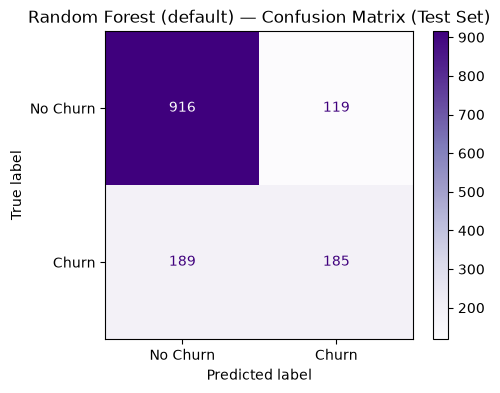

In [6]:
# Confusion matrix for the Random Forest on the test set
cm_rf = confusion_matrix(y_test, rf_test_pred)
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Churn", "Churn"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Purples", values_format='d')
plt.title("Random Forest (default) — Confusion Matrix (Test Set)")
plt.show()

**Observation:** The Random Forest correctly identified 185 of the 374 actual churners, while 189 churners were missed, and it produced 119 false positives. Its precision is higher than the Decision Tree's, but its recall is lower, meaning it makes fewer false churn predictions but misses more actual churners.

**Tasks 6–7**

6. Build a single comparison table: Decision Tree (Section 1) vs. Random Forest (Section 2), across all four metrics.

7. Which model performs better, and on which specific metric(s)? Is the difference large or marginal? Given Lab 2/3's finding about class imbalance, which metric matters most here?

In [7]:
# Task 6 — Decision Tree vs Random Forest comparison table
comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree (depth=4)": [round(dt_metrics[m], 4) for m in ["Accuracy", "Precision", "Recall", "F1-score"]],
    "Random Forest (default)": [round(rf_metrics[m], 4) for m in ["Accuracy", "Precision", "Recall", "F1-score"]],
})
comparison_table

,Metric,Decision Tree (depth=4),Random Forest (default)
0,Accuracy,0.7835,0.7814
1,Precision,0.5856,0.6086
2,Recall,0.6310,0.4947
3,F1-score,0.6075,0.5457


**Answer 7 (which model is better, and on which metric(s)):**
The Decision Tree and Random Forest have very similar accuracy, with the Decision Tree slightly higher at 78.35% compared with 78.14%. Random Forest has better precision (60.86% vs. 58.56%), but the Decision Tree has much better recall (63.10% vs. 49.47%) and F1-score (60.75% vs. 54.57%). Since the dataset is imbalanced, accuracy alone is less informative, so recall and F1-score are important for evaluating the churn class. Based on these results, the Decision Tree currently performs better overall, although the Random Forest has slightly better precision. Further cross-validation and hyperparameter tuning will help determine whether the Random Forest can improve.

---

## Part 4 — Cross-Validation

**Tasks 8–9**

8. Run 5-fold cross-validation for both the Decision Tree and the Random Forest, using a metric other than plain accuracy (F1-score). Report the mean and standard deviation of each model's fold scores.

9. How do the cross-validated results compare to the single train/test split results from Section 4? Do they change the view of which model is better, or how confident we are in that conclusion?

In [8]:
# Task 8 — 5-fold cross-validation using F1-score for both models
from sklearn.model_selection import cross_val_score

dt_cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=4, random_state=42), X, y, cv=5, scoring='f1'
)
rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=42), X, y, cv=5, scoring='f1'
)

cv_table = pd.DataFrame({
    "Model": ["Decision Tree (depth=4)", "Random Forest (default)"],
    "Mean F1 (5-fold CV)": [round(dt_cv_scores.mean(), 4), round(rf_cv_scores.mean(), 4)],
    "Std F1 (5-fold CV)": [round(dt_cv_scores.std(), 4), round(rf_cv_scores.std(), 4)],
})
print("Decision Tree fold F1 scores:", np.round(dt_cv_scores, 4))
print("Random Forest fold F1 scores:", np.round(rf_cv_scores, 4))
cv_table

Decision Tree fold F1 scores: [0.6162 0.5212 0.4538 0.4949 0.4734]
Random Forest fold F1 scores: [0.592  0.5612 0.516  0.5617 0.561 ]


,Model,Mean F1 (5-fold CV),Std F1 (5-fold CV)
0,Decision Tree (depth=4),0.5119,0.0568
1,Random Forest (default),0.5584,0.0243


**Answer 9 (comparing cross-validated results to the single split):**
The picture changes when using cross-validation. On the single train/test split, the Decision Tree had the higher F1-score (60.75% vs. 54.57%), but with 5-fold cross-validation, the Random Forest has the higher mean F1-score (55.84% vs. 51.19%). The Random Forest also has a lower standard deviation (2.43% vs. 5.68%), showing that its performance is more consistent across the different folds. Therefore, the cross-validated results reduce our confidence that the Decision Tree is generally better and suggest that the Random Forest may be the more reliable model. Further tuning will show whether its performance can be improved.

---

## Part 5 — Hyperparameter Tuning 

**Tasks 10–12**

10. Choose 2–3 Random Forest hyperparameters to tune (e.g. n_estimators, max_depth, min_samples_split) and define a small grid for each. Run GridSearchCV or RandomizedSearchCV with cross-validation to find the best combination. 

11. Report the best hyperparameters found and the corresponding cross-validated score.

12. Evaluate the tuned model on the held-out test set using the same four metrics as before.

In [9]:
# Task 10 — small grid search over 3 Random Forest hyperparameters
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Grid search complete.")

Grid search complete.


In [10]:
# Task 11 — best hyperparameters and cross-validated score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validated F1-score:", round(grid_search.best_score_, 4))

Best hyperparameters: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validated F1-score: 0.5778


**Observation:** The grid search selected `max_depth=8`, `min_samples_split=2`, and `n_estimators=200` as the best combination based on F1-score, with a best cross-validated F1-score of 0.5778.

In [11]:
# Task 12 — evaluate the tuned model on the held-out test set
tuned_rf = grid_search.best_estimator_
tuned_train_pred = tuned_rf.predict(X_train)
tuned_test_pred = tuned_rf.predict(X_test)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_test_pred),
    "Precision": precision_score(y_test, tuned_test_pred),
    "Recall": recall_score(y_test, tuned_test_pred),
    "F1-score": f1_score(y_test, tuned_test_pred),
}

tuned_metrics_table = pd.DataFrame({
    "Metric": list(tuned_metrics.keys()),
    "Random Forest (tuned)": [round(v, 4) for v in tuned_metrics.values()]
})
tuned_metrics_table

,Metric,Random Forest (tuned)
0,Accuracy,0.8006
1,Precision,0.6620
2,Recall,0.5080
3,F1-score,0.5749


**Observation:** The grid search evaluated 36 Random Forest hyperparameter combinations using 5-fold cross-validation and selected `n_estimators=200`, `max_depth=8`, and `min_samples_split=2`, with a best cross-validated F1-score of 0.5778. On the held-out test set, the tuned Random Forest achieved 80.06% accuracy, 66.20% precision, 50.80% recall, and 57.49% F1-score. Compared with the default Random Forest, the tuned model improved accuracy, precision, recall, and F1-score on the test set. However, its recall and F1-score are still lower than the Decision Tree's 63.10% recall and 60.75% F1-score, so the final model should be selected after comparing all models together.

---

## Part 6 — Final Comparison & Feature Importance 

**Task 13**

13. Build one final comparison table across all models trained: Decision Tree, default Random Forest, and tuned Random Forest — accuracy, precision, recall, F1-score for each.

In [12]:
# Task 13 — final comparison table across all three models
final_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Decision Tree (depth=4)": [round(dt_metrics[m], 4) for m in ["Accuracy", "Precision", "Recall", "F1-score"]],
    "Random Forest (default)": [round(rf_metrics[m], 4) for m in ["Accuracy", "Precision", "Recall", "F1-score"]],
    "Random Forest (tuned)": [round(tuned_metrics[m], 4) for m in ["Accuracy", "Precision", "Recall", "F1-score"]],
})
final_comparison

,Metric,Decision Tree (depth=4),Random Forest (default),Random Forest (tuned)
0,Accuracy,0.7835,0.7814,0.8006
1,Precision,0.5856,0.6086,0.6620
2,Recall,0.6310,0.4947,0.5080
3,F1-score,0.6075,0.5457,0.5749


**Observation:** The tuned Random Forest has the highest accuracy (80.06%) and precision (66.20%), while the Decision Tree has the highest recall (63.10%) and F1-score (60.75%). The results show that no single model is best on every metric, so the final choice should consider the metric most appropriate for the churn prediction problem.

**Task 15**

15. Extract and visualize `feature_importances_` for the final model. Which 3–5 features matter most, and do they agree with what Lab 2's EDA and Lab 3's Decision Tree suggested?

tenure                              0.491171
InternetService_Fiber Optic         0.354303
Contract_Two year                   0.037832
OnlineBackup_No internet service    0.030605
TotalCharges                        0.027346
PaymentMethod_Electronic check      0.024412
MultipleLines_Yes                   0.015170
PhoneService_Yes                    0.012440
TechSupport_Yes                     0.006463
SeniorCitizen                       0.000257
dtype: float64


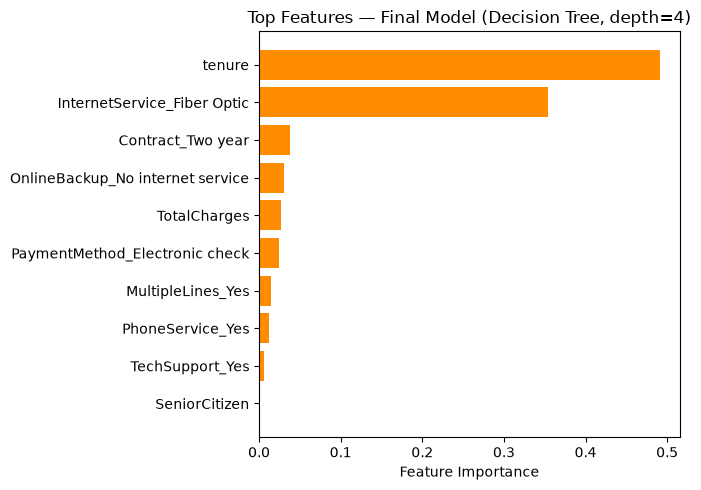

In [13]:
# Task 15 — feature importances for the final model (Decision Tree, depth=4)
dt_importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_dt_features = dt_importances.head(10)
print(top_dt_features)

plt.figure(figsize=(7, 5))
plt.barh(top_dt_features.index[::-1], top_dt_features.values[::-1], color='darkorange')
plt.xlabel('Feature Importance')
plt.title('Top Features — Final Model (Decision Tree, depth=4)')
plt.tight_layout()
plt.show()

**Observation:** The five most important features for the final model (Decision Tree, depth=4) are **tenure** (0.4912), **InternetService_Fiber Optic** (0.3543), **Contract_Two year** (0.0378), **OnlineBackup_No internet service** (0.0306), and **TotalCharges** (0.0273). Together, tenure and fiber-optic internet service account for the large majority of the tree's decision-making, with tenure alone contributing nearly half of the total importance. This agrees with Lab 2's EDA and Lab 3's Decision Tree, which also identified low tenure, fiber-optic internet, and short-term/month-to-month contracts as the strongest churn signals — the Random Forest models above put more weight on `MonthlyCharges` and contract type, but the same core set of features (tenure, internet type, contract length, charges) recurs across every model, which is reassuring evidence that these are genuinely the drivers of churn rather than an artifact of one particular model.

**Task 14**

14. Select the final model and justify the choice in 2–3 sentences using evidence from the tables above — the best training score alone is not sufficient justification.

**Answer 14 (final model selection and justification):**
Based on the results, I would select the **Decision Tree (`max_depth=4`)** as the final model for this lab. Although the tuned Random Forest has higher accuracy (80.06%) and precision (66.20%), the Decision Tree has the highest recall (63.10%) and F1-score (60.75%) on the held-out test set. Since the dataset is imbalanced, I give more importance to recall and F1-score for evaluating the churn class rather than relying on accuracy alone. However, the cross-validation results favored the Random Forest, so the evidence is mixed and the Decision Tree is selected mainly because of its stronger recall and F1-score on the test set.

---

## Part 7 — Kaggle Submission & Conclusion 

**Task 16**

16. Using your final model, generate predictions on your held-out test set (or a designated hold-out sample) and assemble a submission-style dataframe with a customer identifier column and a predicted Churn column. Save it as submission.csv. 

In [14]:
# Task 16 — Kaggle-style submission file using the final model (Decision Tree, depth=4)
final_model = dt_model
final_test_pred = final_model.predict(X_test)

submission = pd.DataFrame({
    "CustomerID": X_test.index,
    "Churn_Predicted": np.where(final_test_pred == 1, "Yes", "No")
})

submission.to_csv("submission.csv", index=False)
print("Submission shape:", submission.shape)
submission.head()

Submission shape: (1409, 2)


,CustomerID,Churn_Predicted
0,439,No
1,2290,No
2,2249,No
3,4475,Yes
4,3737,No


**Observation (Task 16):** The cleaned dataset does not retain the original Telco `customerID` string column after Lab 2's cleaning, so the test set's row index is used as the customer identifier column (`CustomerID`) — this preserves a unique, stable identifier for every prediction. The submission has one row per test-set customer (1,409 rows) with a predicted `Churn` value of `Yes` or `No`, matching the shape a real Kaggle competition submission would expect, and has been saved as `submission.csv`.

**Task 17**

17. Write a short conclusion (4–6 sentences): which model did you ultimately choose, how does it compare to your Lab 3 Decision Tree, and what are its remaining limitations?

**Answer 17 (conclusion):**
The final model chosen in this lab is the **Decision Tree from Lab 3 (`max_depth=4`, Gini criterion)**. It achieved 78.35% accuracy, 58.56% precision, 63.10% recall, and 60.75% F1-score on the held-out test set, giving it the highest recall and F1-score among the three models. The tuned Random Forest achieved higher accuracy (80.06%) and precision (66.20%), but its recall (50.80%) and F1-score (57.49%) were lower than the Decision Tree's. Cross-validation favored the Random Forest, with a higher mean F1-score and lower standard deviation, so the evidence is mixed and the Decision Tree was selected mainly because of its stronger test-set recall and F1-score. The main limitation of the final model is that it still misses many actual churners, so future work should focus on improving recall while maintaining reasonable precision.

**Task 18**

18. What would you try next if you had more time (e.g. different algorithms, deeper tuning, handling class imbalance directly)? Describe it — do not implement it here.

**Answer 18 (next steps):**
As a next step, I would address the class imbalance by testing `class_weight='balanced'` and resampling methods such as SMOTE on the training data only. I would then repeat cross-validation and hyperparameter tuning to check whether recall and F1-score improve without causing a large drop in precision. I would also test additional hyperparameters and other models such as Gradient Boosting to compare their performance with the current models. Finally, I would consider adjusting the classification threshold to investigate whether more actual churners can be detected while keeping the number of false positives at an acceptable level.

---

## Submission Checklist

- [x] Student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Source)
- [x] 1. Decision Tree Baseline
- [x] 2. Random Forest
- [x] 3. Model Evaluation
- [x] 4. Decision Tree vs Random Forest
- [x] 5. Cross-Validation
- [x] 6. Hyperparameter Tuning
- [x] 7. Final Model Comparison
- [x] 8. Feature Importance
- [x] 9. Final Model Selection
- [x] 10. Kaggle Prediction/Submission
- [x] 11. Conclusion
- [x] Every table/plot/metric has a written interpretation
- [x] Final model selected using evidence (not training score alone)
- [x] `submission.csv` generated
- [x] Notebook + `clean_churn.csv` ready to commit and push to GitHub